# HW5: Linear Regression and Classification

This homework consists of two main parts: Part 1 (Linear Regression) and Part 2 (Real / Fake News Classification).

# Part 1. Linear Regression (Section 1 - Section 4)
Over the course of the following part you'll walk through a guided tutorial on **Regression** and its uses.

* We'll start with looking at regression on different relations in data (linear, quadratic, etc.).

* Then you'll work on building your own regression tool.

* You'll finish the homework by tying the ideas of these different relations (linear, quadratic) into neural networks to understand **why** we use neural networks.


### Section 1 : Basic Linear Regression (25 points)

Let's begin with **some straightforward linear regression** on some basic datasets. Take a look at the data we are using below.

##### Dataset Preparation (DO NOT MODIFY!)
Below is the essential code for preparing our dataset for analysis. **Please do not alter this code**. Instead, observe and understand the steps being taken.

Once our dataset is ready, we will proceed to train our linear regression model and evaluate how well it explains the data.


The dataset includes:

- (1) "linear" : Synthetic linear data from make_regression
- (2) "convex" : A second-order polynomial dataset
- (3) "trigonometric" : A high-order trigonometric dataset

**Note: you might need ` pip install "scikit-learn==1.8.0"` to run the following task.**

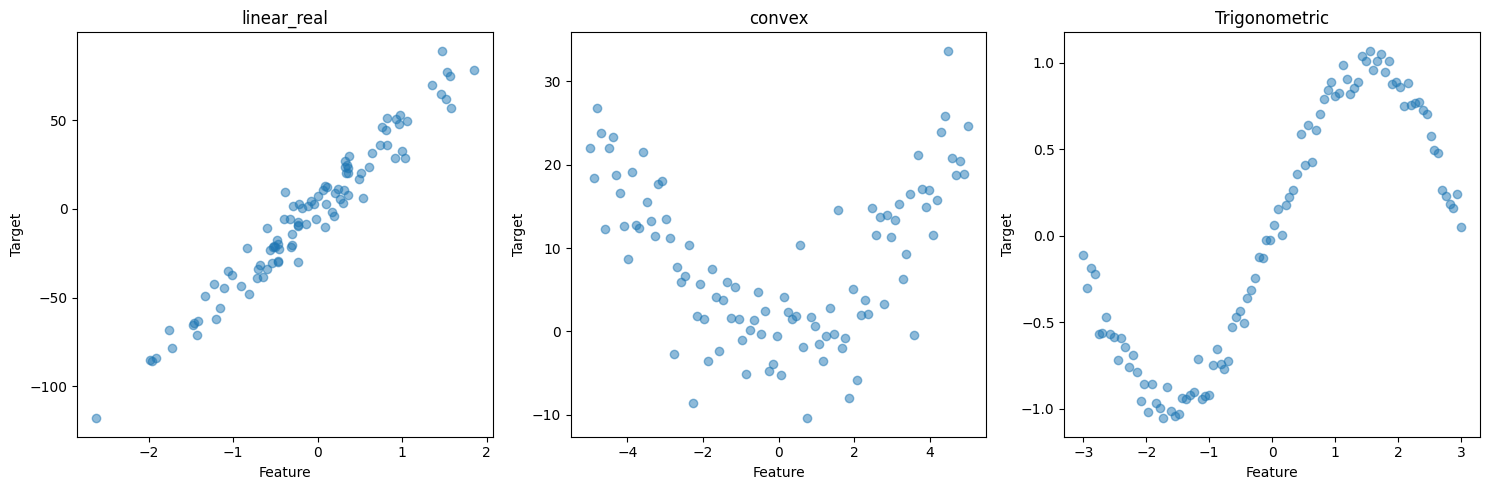

In [56]:
### DO NOT MODIFY
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_s_curve
import transformers
import time

transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

X_linear, y_linear = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# (2) "convex" like dataset
X_convex = np.linspace(-5, 5, 100).reshape(-1, 1)
y_convex = X_convex**2 + np.random.normal(0, 5, size=100).reshape(-1, 1)
y_convex = y_convex.flatten()

# (3) "S-shaped curve" dataset (alternative to trigonometric)
# X_s_curve, y_s_curve = make_s_curve(n_samples=100, noise=0.1, random_state=42)
X_s_curve, y_s_curve = np.linspace(-3, 3, 100).reshape(-1, 1), np.sin(np.linspace(-3, 3, 100)) + np.random.default_rng(42).normal(0, 0.1, 100)
X_s_curve = X_s_curve[:, 0].reshape(-1, 1) # Use only the first feature for simplicity

datasets = {
    "linear_real": (X_linear, y_linear),
    "convex": (X_convex, y_convex),
    "Trigonometric": (X_s_curve, y_s_curve)
}

# Create the subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each dataset
for ax, dataset in zip(axes, datasets.items()):
    title, (X, y) = dataset
    ax.scatter(X, y, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Target')

plt.tight_layout()
plt.show()
### DO NOT MODIFY

Above, we visualize these datasets for you to gather some ideas about how they look. Look at the visualizations and consider: What are your thoughts on using linear regression to model the non-linear patterns observed in the convex and trigonometric datasets? Do you believe linear regression is adaptable enough to accurately capture these complex relationships? (THIS IS NOT A TASK, JUST A WARM-UP for your thought process before you start working on your tasks next)

##### 1.1. Preparation of Training and Testing Sets (3 pts)

**TASK**: Implement the **split_data** function

We will now divide our three datasets into training and testing sets. For this task, you might want utilize the *train_test_split* function from *sklearn*. This step is crucial for preparing our data for the upcoming linear regression modeling, ensuring that we have separate sets for training our models and evaluating their performance.

In [57]:
# DO NOT MODIFY
from sklearn.model_selection import train_test_split

X_linear, Y_linear = datasets["linear_real"]
X_convex, Y_convex = datasets["convex"]
X_tri, Y_tri = datasets["Trigonometric"]

random_state = 42
np.random.seed(random_state)
test_size = 0.2

def split_data(X, Y, test_size=test_size, random_state=random_state):
    # YOUR CODE HERE (1-2 lines)
    return train_test_split(X, Y, test_size=test_size, random_state=random_state)

# DO NOT MODIFY
# Apply the function for each dataset
X_linear_train, X_linear_test, Y_linear_train, Y_linear_test = split_data(X_linear, Y_linear)
X_convex_train, X_convex_test, Y_convex_train, Y_convex_test = split_data(X_convex, Y_convex)
X_tri_train, X_tri_test, Y_tri_train, Y_tri_test = split_data(X_tri, Y_tri)

Now, let's **visualize our split dataset**. You can just use the given function to plot each of the dataset.

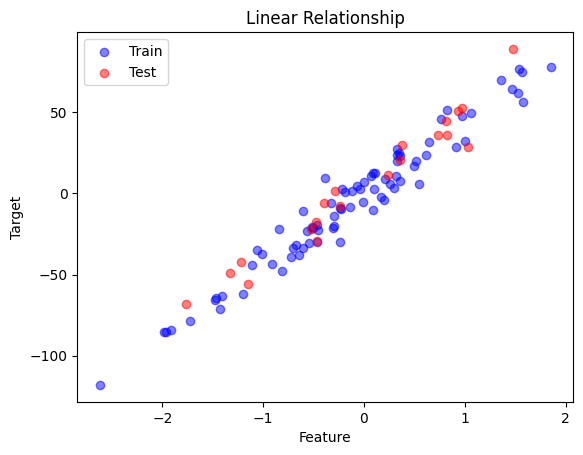

In [58]:
# Set the variable to select the model to plot
selected_dataset = 'Linear'  # Choose between 'Linear', 'Convex', 'Trigonometric'

# DO NOT MODIFY
def draw_scatter(X_train, Y_train, X_test, Y_test, title, xlabel='Feature', ylabel='Target'):
    plt.scatter(X_train, Y_train, color='blue', label='Train', alpha=0.5)
    plt.scatter(X_test, Y_test, color='red', label='Test', alpha=0.5)
    plt.title(title)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# Dictionary to store datasets
datasets = {
    'Linear': (X_linear_train, Y_linear_train, X_linear_test, Y_linear_test, 'Linear Relationship'),
    'Convex': (X_convex_train, Y_convex_train, X_convex_test, Y_convex_test, 'Convex Relationship'),
    'Trigonometric': (X_tri_train, Y_tri_train, X_tri_test, Y_tri_test, 'Trigonometric Relationship')
}

# Extract selected dataset
X_train, Y_train, X_test, Y_test, title = datasets[selected_dataset]

# Plot the selected dataset
draw_scatter(X_train, Y_train, X_test, Y_test, title)

##### 1.2. Linear Regression: Fit a line for the given dataset (6 pts)

**TASK**: Implement the ***fit_model*** and ***predict_data*** functions

You must fit on the training data and then do predictions for both the training and test sets. Use the training prediction for plotting, and the test prediction for evaluation.

*Hint: You can use LinearRegssion from sklearn.linear_model*

In [59]:
from sklearn.linear_model import LinearRegression

# Function to fit the model
def fit_model(X_train, Y_train):
    # YOUR CODE HERE (1-2 lines)
    model = LinearRegression()
    model.fit(X_train, Y_train)
    return model

# Function to predict using the fitted model
def predict_data(model, X_train, X_test):
    # YOUR CODE HERE (1-2 lines)
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    return Y_train_pred, Y_test_pred


# DO NOT MODIFY
# Fit the model for each dataset and predict
linear_model = fit_model(X_linear_train, Y_linear_train)
Y_linear_train_pred, Y_linear_test_pred = predict_data(linear_model, X_linear_train, X_linear_test)
convex_model = fit_model(X_convex_train, Y_convex_train)
Y_convex_train_pred, Y_convex_test_pred = predict_data(convex_model, X_convex_train, X_convex_test)
trigonometric_model = fit_model(X_tri_train, Y_tri_train)
Y_tri_train_pred, Y_tri_test_pred = predict_data(trigonometric_model, X_tri_train, X_tri_test)


Plots below! We'll use the test predictions later.

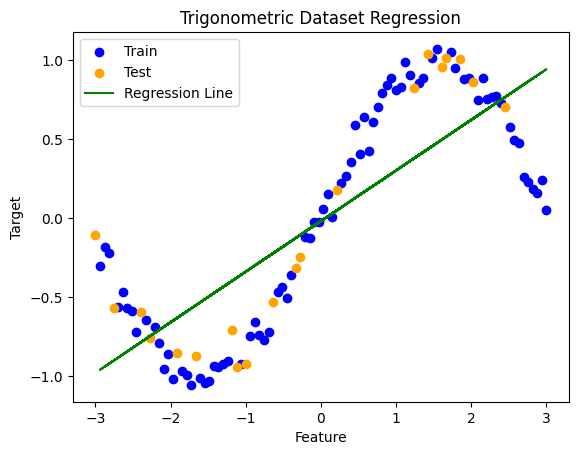

In [60]:
# Set the variable to select the model to plot
selected_dataset = 'Trigonometric'  # Choose between 'Linear', 'Convex', 'Trigonometric'

# DO NOT MODIFY
# Function to draw scatter plot with regression line
def draw_scatter_with_regression(X_train, Y_train, X_test, Y_test, Y_train_pred, title, xlabel='Feature', ylabel='Target'):
    plt.scatter(X_train, Y_train, color='blue', label='Train')
    plt.scatter(X_test, Y_test, color='orange', label='Test')
    plt.plot(X_train, Y_train_pred, color='green', label='Regression Line')
    plt.title(title)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.legend()
    plt.show()

# Dictionary to store datasets and predictions
datasets = {
    'Linear': (X_linear_train, Y_linear_train, X_linear_test, Y_linear_test, Y_linear_train_pred, 'Linear Dataset Regression'),
    'Convex': (X_convex_train, Y_convex_train, X_convex_test, Y_convex_test, Y_convex_train_pred, 'Convex Dataset Regression'),
    'Trigonometric': (X_tri_train, Y_tri_train, X_tri_test, Y_tri_test, Y_tri_train_pred, 'Trigonometric Dataset Regression')
}

# Extract selected dataset
X_train, Y_train, X_test, Y_test, Y_train_pred, title = datasets[selected_dataset]

# Plot the selected dataset with regression line
draw_scatter_with_regression(X_train, Y_train, X_test, Y_test, Y_train_pred, title)


##### 1.3. Linear Model Evaluation (4 pts)
**TASK**: implement the ***evaluate_model*** function, which calculates the Mean Squared Error (MSE) and $R^2$ coefficient for each training and test split.

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate MSE and R^2
def evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred):
    # YOUR CODE HERE
    mse_train = mean_squared_error(Y_train, Y_train_pred)
    mse_test = mean_squared_error(Y_test, Y_test_pred)
    r2_train = r2_score(Y_train, Y_train_pred)
    r2_test = r2_score(Y_test, Y_test_pred)
    return mse_train, mse_test, r2_train, r2_test

# DO NOT MODIFY
# Apply the function for each dataset
mse_linear_train, mse_linear_test, r2_linear_train, r2_linear_test = evaluate_model(
    Y_linear_train, Y_linear_train_pred, Y_linear_test, Y_linear_test_pred)

mse_convex_train, mse_convex_test, r2_convex_train, r2_convex_test = evaluate_model(
    Y_convex_train, Y_convex_train_pred, Y_convex_test, Y_convex_test_pred)

mse_tri_train, mse_tri_test, r2_tri_train, r2_tri_test = evaluate_model(
    Y_tri_train, Y_tri_train_pred, Y_tri_test, Y_tri_test_pred)


In [62]:
# DO NOT MODIFY
# List of datasets and their metrics
datasets = ["Linear", "Convex", "Trigonometric"]
mse_train = [mse_linear_train, mse_convex_train, mse_tri_train]
mse_test = [mse_linear_test, mse_convex_test, mse_tri_test]
r2_train = [r2_linear_train, r2_convex_train, r2_tri_train]
r2_test = [r2_linear_test, r2_convex_test, r2_tri_test]

# Function to store and display results
def store_and_display_results(datasets, mse_train, mse_test, r2_train, r2_test):
    results = []
    for i, dataset in enumerate(datasets):
        result = {
            "Dataset": dataset,
            "MSE Train": mse_train[i],
            "MSE Test": mse_test[i],
            "R2 Train": r2_train[i],
            "R2 Test": r2_test[i]
        }
        results.append(result)

        # Display the results
        print(f"{dataset} Dataset:")
        print(f"  MSE Train: {mse_train[i]:.4f}")
        print(f"  MSE Test: {mse_test[i]:.4f}")
        print(f"  R2 Train: {r2_train[i]:.4f}")
        print(f"  R2 Test: {r2_test[i]:.4f}")
        print()  # Blank line for readability

    return results

# Store and display the results
results = store_and_display_results(datasets, mse_train, mse_test, r2_train, r2_test)


Linear Dataset:
  MSE Train: 72.9225
  MSE Test: 104.2022
  R2 Train: 0.9564
  R2 Test: 0.9374

Convex Dataset:
  MSE Train: 95.6090
  MSE Test: 61.2797
  R2 Train: 0.0020
  R2 Test: -0.1389

Trigonometric Dataset:
  MSE Train: 0.1798
  MSE Test: 0.1622
  R2 Train: 0.6354
  R2 Test: 0.7146



##### 1.4. Discussion about the Evaluation Results. (4 pts)

**TASK**: Answer following questions:

<!-- - (1) For each dataset among "Linear", "Convex", and "Trigonometric", does the model perform well based on the MSE and $R^2$ values? Answer "Yes" or "No" for each dataset. -->
- (1) For which dataset(s) does the linear model appear to be a good fit, and for which does it perform poorly? Justify your answer by referring to the metrics.

- (2) What does it mean if the $R^2$ coefficient is 0? What does it mean if it is 1? Provide a brief explanation for each case.


(1) The linear model performs well onl on the linear dataset, where R^2 scores of 0.956 (train) and 0.937 (test) confirm that the model explains roughly 94% of the variance with consistent performance across both splits. For the convex dataset, the model essentially fails because teh R^2 drops o near 0 on training and goes negative on testing. This meanes that a sstriaght line cannot capture the parabolic relationship at all which makes sense. The trigonometric dataset ladns somehwere in the middle, with R^2 around 0.63-0.71, but I think that is more coincidental than not because the model might just be picking up the genreal diagonal trend of the sine wave.

(2) An R^2 of 0 means themodel explains none of the vairaince in the target variable and performs no better than simply predicting the mean of Y for every input. Basically, it says the features are providing no useful information to predict from. An R^2 of 1 means that the model explains all of the variance perfectly, which means every prediction matches the true value exactly and no residual error remains. However, and R^2 of 1 is really rare and it could be a sign that the model is overfitting rather than being perfect.

##### 1.5. Implement Polynomial Features (8 pts)

**TASK**: implement the ***fit_model_poly*** and ***predict_data_poly*** functions

In this section, we'll explore how to use polynomial features to transform non-linear relationships into linear ones, enabling us to apply linear regression effectively. The basic idea is think about non-linear relationships in a higher dimension. But how can we do that? Let's try with polynomial features.


You can think of these features like this...

Consider the following:

* $ y = x^2$ is non linear right?
* What if we said $\alpha = x^2$, so $y = \alpha$?
*Then if you plot $y$ versus $\alpha$ you would get a linear relationship!

Given the provided code below, your task is to implement polynomial regression models for three distinct datasets: linear, convex, and trigonometric to predict outcomes for both training and test data for each dataset :


We recommend using the sklearn ['make_pipeline'](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) and ['PolynomialFeatures'](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures) for this part.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# Function to fit the polynomial model
def fit_model_poly(X_train, Y_train, degree):
    # YOUR CODE HERE
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, Y_train)
    return model

# Function to predict using the fitted polynomial model
def predict_data_poly(model, X_train, X_test):
    # YOUR CODE HERE
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    return Y_train_pred, Y_test_pred

# DO NOT MODIFY
# Define degrees for polynomial features
degree_linear = 1  # For the linear dataset, a degree of 1 is just a linear relationship
degree_convex = 3  # For the convex dataset, let's try a quadratic model
degree_tri = 8    # For the trigonometric dataset, a higher degree might capture the sine/cosine waves

# Fit and predict for the linear dataset
linear_model_poly = fit_model_poly(X_linear_train, Y_linear_train, degree_linear)
Y_linear_train_pred_poly, Y_linear_test_pred_poly = predict_data_poly(linear_model_poly, X_linear_train, X_linear_test)

# Fit and predict for the convex dataset
convex_model_poly = fit_model_poly(X_convex_train, Y_convex_train, degree_convex)
Y_convex_train_pred_poly, Y_convex_test_pred_poly = predict_data_poly(convex_model_poly, X_convex_train, X_convex_test)

# Fit and predict for the trigonometric dataset
trigonometric_model_poly = fit_model_poly(X_tri_train, Y_tri_train, degree_tri)
Y_tri_train_pred_poly, Y_tri_test_pred_poly = predict_data_poly(trigonometric_model_poly, X_tri_train, X_tri_test)


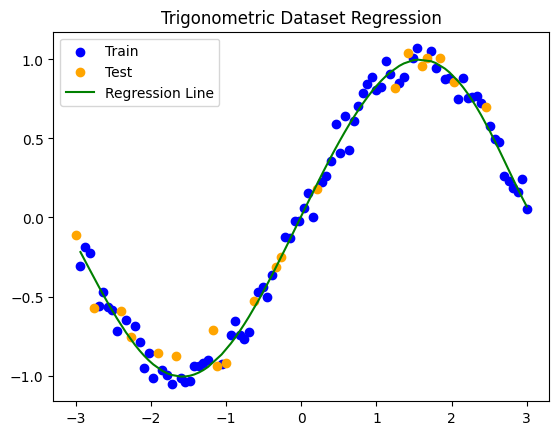

In [64]:
# Set the variable to select the model to plot
selected_dataset = 'Trigonometric'  # Choose between 'Linear', 'Convex', 'Trigonometric'

# DO NOT MODIFY
# Function to plot dataset with regression line
def plot_dataset_with_regression(X_train, Y_train, X_test, Y_test, Y_train_pred, title):
    sorted_idx = np.argsort(X_train.ravel())
    plt.scatter(X_train, Y_train, color='blue', label='Train')
    plt.scatter(X_test, Y_test, color='orange', label='Test')
    plt.plot(X_train[sorted_idx], Y_train_pred[sorted_idx], color='green', label='Regression Line')
    plt.title(title)
    plt.legend()
    plt.show()

# Dictionary to store datasets and predictions
datasets = {
    'Linear': (X_linear_train, Y_linear_train, X_linear_test, Y_linear_test, Y_linear_train_pred_poly, 'Linear Dataset Regression'),
    'Convex': (X_convex_train, Y_convex_train, X_convex_test, Y_convex_test, Y_convex_train_pred_poly, 'Convex Dataset Regression'),
    'Trigonometric': (X_tri_train, Y_tri_train, X_tri_test, Y_tri_test, Y_tri_train_pred_poly, 'Trigonometric Dataset Regression')
}

# Extract selected dataset
X_train, Y_train, X_test, Y_test, Y_train_pred, title = datasets[selected_dataset]

# Plot the selected dataset with regression line
plot_dataset_with_regression(X_train, Y_train, X_test, Y_test, Y_train_pred, title)


In [65]:
# DO NOT MODIFY

# Calculate for all datasets
mse_linear_train_poly, mse_linear_test_poly, r2_linear_train_poly, r2_linear_test_poly = evaluate_model(
    Y_linear_train, Y_linear_train_pred_poly, Y_linear_test, Y_linear_test_pred_poly)

mse_convex_train_poly, mse_convex_test_poly, r2_convex_train_poly, r2_convex_test_poly = evaluate_model(
    Y_convex_train, Y_convex_train_pred_poly, Y_convex_test, Y_convex_test_pred_poly)

mse_tri_train_poly, mse_tri_test_poly, r2_tri_train_poly, r2_tri_test_poly = evaluate_model(
    Y_tri_train, Y_tri_train_pred_poly, Y_tri_test, Y_tri_test_pred_poly)

# Print the MSE and R^2 values for both training and testing sets for each dataset with polynomial features
print("Linear Dataset with Polynomial Features:")
print(f"Train - MSE: {mse_linear_train_poly:.4f}, R^2: {r2_linear_train_poly:.4f}")
print(f"Test - MSE: {mse_linear_test_poly:.4f}, R^2: {r2_linear_test_poly:.4f}\n")

print("Convex Dataset with Polynomial Features:")
print(f"Train - MSE: {mse_convex_train_poly:.4f}, R^2: {r2_convex_train_poly:.4f}")
print(f"Test - MSE: {mse_convex_test_poly:.4f}, R^2: {r2_convex_test_poly:.4f}\n")

print("Trigonometric Dataset with Polynomial Features:")
print(f"Train - MSE: {mse_tri_train_poly:.4f}, R^2: {r2_tri_train_poly:.4f}")
print(f"Test - MSE: {mse_tri_test_poly:.4f}, R^2: {r2_tri_test_poly:.4f}\n")

Linear Dataset with Polynomial Features:
Train - MSE: 72.9225, R^2: 0.9564
Test - MSE: 104.2022, R^2: 0.9374

Convex Dataset with Polynomial Features:
Train - MSE: 25.3543, R^2: 0.7353
Test - MSE: 34.8905, R^2: 0.3515

Trigonometric Dataset with Polynomial Features:
Train - MSE: 0.0049, R^2: 0.9901
Test - MSE: 0.0083, R^2: 0.9855



### Section 2: Linear Regression Model Design (25 points)

The mean-squared error loss is one of the basic loss that can be used for linear regression.

$$L_\text{MSE} = \frac{1}{n}\sum_{i=1}^n(\hat{Y}_i - Y_i)^2$$
$$\hat{Y}_i = \theta_1 X_i + \theta_2$$

Reminder: $\frac{\partial f}{\partial x}$ means taking the derivative of $f$ with respect to $x$, assuming ALL other variables are constants.

Sources:

https://tutorial.math.lamar.edu/classes/calciii/partialderivatives.aspx

https://tutorial.math.lamar.edu/classes/calci/DerivativeIntro.aspx



##### 2.1. Derive the gradients $\frac{\partial L}{\partial\theta_1}, \frac{\partial L}{\partial\theta_2}$ (5 pts).



**Student Response** (preferred latex, equation must be readable)

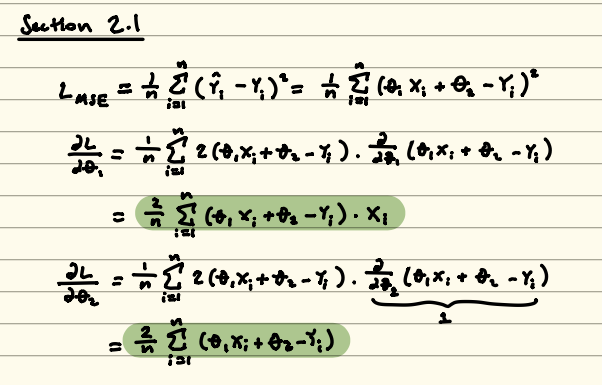

##### 2.2 Implement our SimpleLinearRegression class (12 pts)





**TASK**: Your task is to complete the implementation of a Simple Linear Regression model using gradient descent from scratch.

You may have to follow these steps: <br>

* Initialize model parameters.
* Implement gradient descent to iteratively update the model parameters.

In [66]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleLinearRegression:
    def __init__(self, iterations=1000, learning_rate=0.01):
        self.iterations = iterations
        self.learning_rate = learning_rate
        # YOUR CODE HERE
        self.m = 0.0
        self.b = 0.0

    def fit(self, X, Y):
        # YOUR CODE HERE
        n = len(Y)
        for _ in range(self.iterations):
            Y_pred = self.m * X + self.b

            residuals = Y_pred - Y

            grad_m = (2/n) * np.sum(residuals * X)
            grad_b = (2/n) * np.sum(residuals)

            self.m -= self.learning_rate * grad_m
            self.b -= self.learning_rate * grad_b


    def predict(self, X):
        # YOUR CODE HERE
        return self.m * X + self.b

The following code will test your implementation.

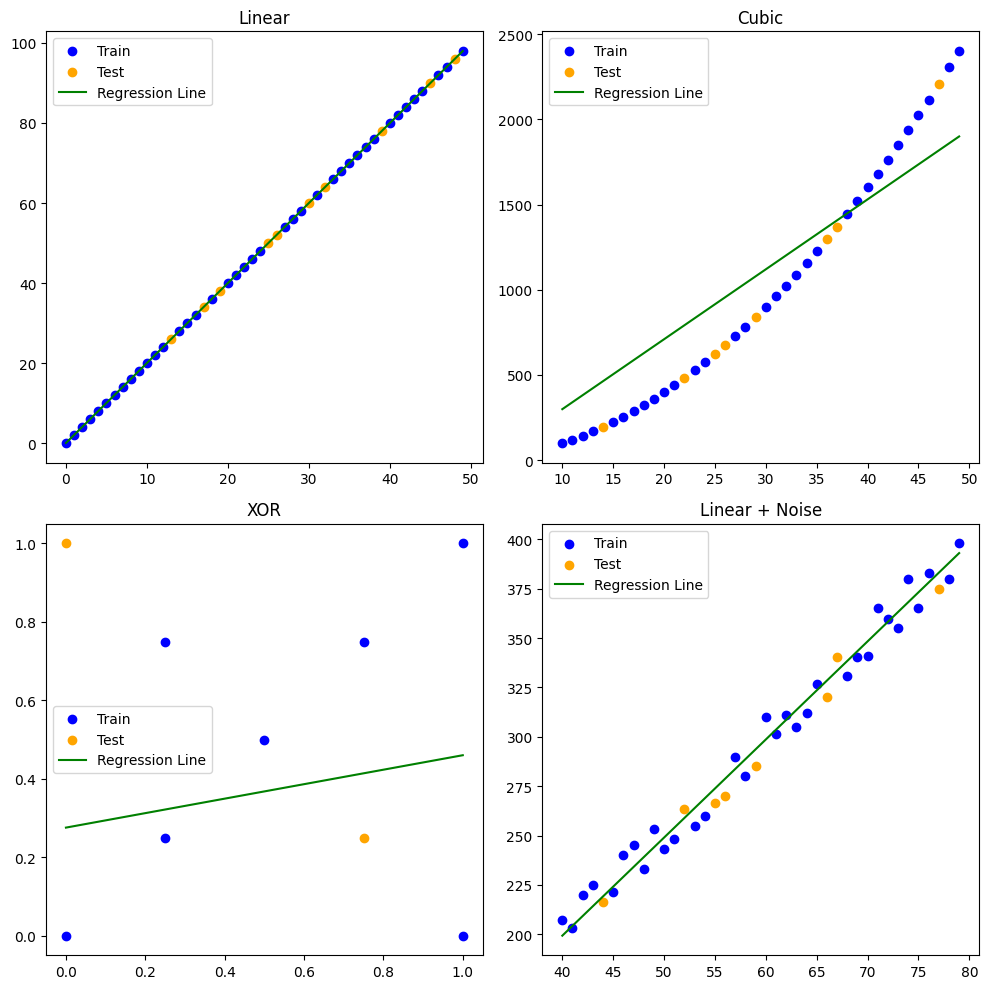

Good job!


In [67]:
### DO NOT MODIFY
def test_linear_regression(model, X_train, X_test, Y_train, Y_test):
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)

    metric = max(Y_test)


    relative_error = np.mean(np.abs((Y_test - predictions)/metric))
    return relative_error < 0.05

datasets = [
   (np.arange(0, 50), np.arange(0, 50)*2),
    (np.arange(10, 50), np.arange(10, 50)**2),
   (np.array([0, 0, 1, 1, 0.25, 0.25, 0.75, 0.75, 0.5]), np.array([0, 1, 1, 0, 0.25, 0.75, 0.75, 0.25, 0.5])),
    (np.arange(40, 80), np.arange(40,80)*5 + np.random.normal(0, 15, 40).clip(-10, 10))
]

datasets = [split_data(X, Y, 0.2) for X, Y in datasets]

# Visualize regression
def visualize_datasets(datasets, titles):
    plt.figure(figsize=(10, 10))
    for idx, dataset in enumerate(datasets):
        X_train, X_test, Y_train, Y_test = dataset

        model = SimpleLinearRegression(iterations=6000, learning_rate=1e-4)
        model.fit(X_train, Y_train)
        Y_train_pred = model.predict(X_train)

        sorted_idx = np.argsort(X_train.ravel())
        plt.subplot(2, 2, idx + 1)
        plt.scatter(X_train, Y_train, color='blue', label='Train')
        plt.scatter(X_test, Y_test, color='orange', label='Test')
        plt.plot(X_train[sorted_idx], Y_train_pred[sorted_idx], color='green', label='Regression Line')
        plt.title(titles[idx])
        plt.legend()

    plt.tight_layout()
    plt.show()

titles = ["Linear", "Cubic", "XOR", "Linear + Noise"]
visualize_datasets(datasets, titles)

# Test each dataset
results = [test_linear_regression(SimpleLinearRegression(iterations=10000, learning_rate=1e-4), *dataset) for dataset in datasets]
answers = [True, False, False, True]
if results == answers:
  print("Good job!")
else:
  print("Wrong Implmentation! Your linear regression model needs more testing!")
  assert(False)

### DO NOT MODIFY

##### 2.3 Implement multi-variate linear regression pipeline. (8 pts)
**TASK**:
- Implement your *LinearRegression* model, which is multi-variate version of *SimpleLinearRegression* model from Q.2.2
- Design your pipeline to learn the given traffic dataset with polynomial features.
- Predict the traffic volume for 6 AM and 6 PM.

**Hints**:
- You can integrate **StandardScaler** into your model pipeline. If the dataset is normalized, the model can learn the dataset more effectively.




In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split  # Added missing import
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

### DO NOT MODIFY: Dataset Preparation
num_samples = 800
X = np.linspace(0, 24, num_samples)
x_norm = (X - 12) / 12
Y = (200 - 500 * x_norm**4 + 1800 * x_norm**2 + 500 * x_norm**3) * 50  #+ np.random.normal(0, 500.0, num_samples).clip(-2000, 2000)
#Y = (150 - 400 * x_norm**3 + 1500 * x_norm**2 + 600 * x_norm**4) * 60 + np.random.normal(0, 400.0, num_samples).clip(-1500, 1500)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

class LinearRegression:
    def __init__(self, iterations=1000, learning_rate=0.1):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.weights = None  # will be initialized in fit
        self.bias = 0.0

    def fit(self, X, Y):
        X = np.asarray(X)
        Y = np.asarray(Y).reshape(-1, 1)
        n, d = X.shape

        ### YOUR CODE HERE
        self.weights = np.zeros((d, 1))

        for iter in range(self.iterations):
            ### YOUR CODE HERE
            Y_pred = np.dot(X, self.weights) + self.bias
            residuals = Y_pred - Y

            grad_w = (2/n) * np.dot(X.T, residuals)
            grad_b = (2/n) * np.sum(residuals)

            self.weights -= self.learning_rate * grad_w
            self.bias -= self.learning_rate * grad_b

        return self

    def predict(self, X):
        X = np.asarray(X)
        return np.dot(X, self.weights) + self.bias

print(X.shape, Y.shape)
### YOUR CODE HERE
model = make_pipeline(PolynomialFeatures(degree=4), StandardScaler(), LinearRegression())
model.fit(X_train.reshape(-1, 1), Y_train)


(800,) (800,)


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=4)),
                ('standardscaler', StandardScaler()),
                ('linearregression',
                 <__main__.LinearRegression object at 0x7a064aa6dc70>)])

The following code will visualize your regression results. Use the model to predict the traffic volume for 6 AM and 6 PM.

Traffic at 6 AM:  27254.709801240257
Traffic at 6 PM:  34074.54205340857


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


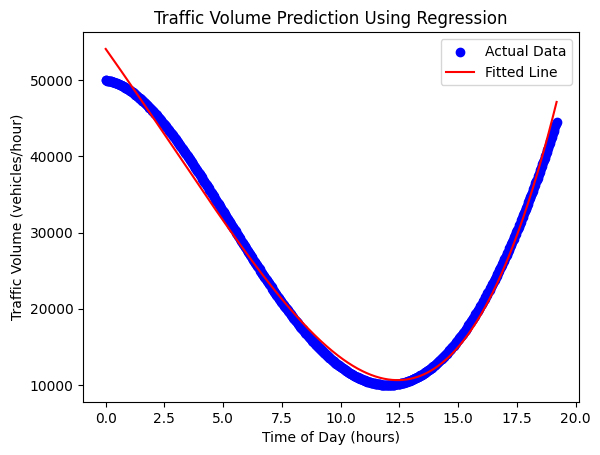

Predicted traffic volume at 6 AM: [[27254.70980124]]
Predicted traffic volume at 6 PM: [[34074.54205341]]


In [69]:
### DO NOT MODIFY
traffic_at_6am = model.predict(np.array([[6]]))
traffic_at_6pm = model.predict(np.array([[18]]))

print("Traffic at 6 AM: ", traffic_at_6am.item())
print("Traffic at 6 PM: ", traffic_at_6pm.item())

def plot_regression_line(model, X, Y):
    # Predict values using the fitted model
    X = X.reshape(-1, 1)
    Y_pred = model.predict(X)

    # Plot the actual data and the fitted regression line
    plt.scatter(X, Y, color='blue', label='Actual Data')
    plt.plot(X, Y_pred, color='red', label='Fitted Line')
    plt.title('Traffic Volume Prediction Using Regression')
    plt.xlabel('Time of Day (hours)')
    plt.ylabel('Traffic Volume (vehicles/hour)')
    plt.legend()
    plt.show()

plot_regression_line(model, X_train, Y_train)
print("Predicted traffic volume at 6 AM:", traffic_at_6am)
print("Predicted traffic volume at 6 PM:", traffic_at_6pm)


### Section 3: Neural Networks (25 points)

We want you to perform a real world regression all on your own. You know the fundamental underlying ideas, so let's use some real world libraries and methods to actually do regression on a **real** dataset.

We'll be using pytorch for this next section. Look at (https://pytorch.org/tutorials/beginner/basics/intro.html) for a run down on pytorch basics.


##### 3.1. Preparation of Data Loaders (10 pts)

**TASK**: Prepare **train_loader** and **test_loader**.

**Requirements**:
- Use **train_test_split** to set aside **20%**of the entire dataset as the test set.
- Set the **batch size** to **32** for both loaders.
- Normalize the dataset using StandardScaler to make it **zero mean** and **unit variance** for each feature dimension.
- Ensure that **train_loader** samples the dataset randomly (refer to the **shuffle** argument in DataLoader).
- Set **batch_size**, **num_train_data**, **num_test_data**, **feat_dim** values from your train/test loaders. **num_X_data** refers to the number of data samples, not the number of batches. **DO NOT HARDCODE THESE VALUES**



In [70]:
### DO NOT MODIFY HERE!
# from sklearn.datasets import fetch_california_housing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os, torch
torch.set_num_threads(os.cpu_count() or 1)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data
housing = fetch_openml(name="house_prices", as_frame=True)

X, y = housing.data, housing.target

In [71]:
### YOUR ANSWER HERE

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numeric columns based on the training data
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# Preprocess training and testing data: select numeric columns and fill NaNs
# Calculate mean from the numeric columns of the TRAINING set only to avoid data leakage
train_mean = X_train[numeric_cols].mean()
X_train_numeric = X_train[numeric_cols].fillna(train_mean)
X_test_numeric = X_test[numeric_cols].fillna(train_mean)


# Normalize the data (separate scalers for X and y so statistics are not overwritten)
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train_numeric)
X_test_scaled = x_scaler.transform(X_test_numeric)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))


# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)


# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch_size = train_loader.batch_size
num_train_data = len(train_dataset)
num_test_data = len(test_dataset)
feat_dim = train_loader.dataset[0][0].shape[0]

In [72]:
### DO NOT MODIFY HERE!
try:
    assert(type(train_loader) == DataLoader)
    assert(type(test_loader) == DataLoader)
except:
    print('"train_loader" and "test_loader" must be DataLoader type!')

print("Batch Size:", batch_size)
print("Number of Train Data:", num_train_data)
print("Number of Test Data:", num_test_data)
print("Feature Dimension:", feat_dim)

Batch Size: 32
Number of Train Data: 1168
Number of Test Data: 292
Feature Dimension: 37


##### 3.2. Define Multi-Layer Perceptron Model (5 pts)

**TASK**: Implement the **MLPModel** and instantiate
 the **model** variable.

**Requirements**:
- The MLP model consists of four fully-connected linear layers.
- Use **relu** activation functions between each layer
- Do not apply the activation function to the final output. (It should directly come from the linear layer. Why? Think about it)

In [73]:
### YOUR ANSWER HERE
class MLPModel(nn.Module):
    def __init__(self, feat_dim):
        super(MLPModel, self).__init__()
        ### YOUR CODE HERE.
        self.fc1 = nn.Linear(feat_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)


    def forward(self, x):
        ### YOUR CODE HERE.
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


# Instantiate the model
model = MLPModel(feat_dim=feat_dim)

In [74]:
### DO NOT MODIFY HERE!
try:
    assert(type(model) == MLPModel)
except:
    print('"model" must be MLPModel type!')

num_layers = len(list(model.children()))
input_dim = list(model.children())[0].in_features
output_dim = list(model.children())[-1].out_features

print("Number of Layers:", num_layers)
print("Input Dimension:", input_dim)
print("Output Dimension:", output_dim)

Number of Layers: 4
Input Dimension: 37
Output Dimension: 1


##### 3.3. Implement the MLP Training Loop (10 pts)

**TASK**: Implement the training loop with adequate loss function and optimizer.

**Requirements**:
- Use the **Adam** optimizer and the **MSELoss** function.
- Your training training loop should implement both the forward pass (calculating losses) and the backward pass(zeroing the graidng and updating the parameters from the loss gradients)

In [75]:
### YOUR ANSWER HERE
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
losses = []
for epoch in range(epochs):
    running_loss = 0.0
    n_batches = 0
    for batch_idx, (data, targets) in enumerate(train_loader):
        ### YOUR ANSWER HERE
        # Forward pass
        outputs = model(data)
        loss = criterion(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches +=1


    epoch_loss = running_loss / n_batches
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss}')

print('Finished Training')

Epoch 1/100, Loss: 0.537631878176251
Epoch 2/100, Loss: 0.1922241896390915
Epoch 3/100, Loss: 0.19484426292615967
Epoch 4/100, Loss: 0.14008535464873184
Epoch 5/100, Loss: 0.12947787681745515
Epoch 6/100, Loss: 0.11502580087933992
Epoch 7/100, Loss: 0.09763154382439884
Epoch 8/100, Loss: 0.08631209515639253
Epoch 9/100, Loss: 0.07493579307117977
Epoch 10/100, Loss: 0.06724019091878389
Epoch 11/100, Loss: 0.05777239668610934
Epoch 12/100, Loss: 0.05435719643090222
Epoch 13/100, Loss: 0.04858480439194151
Epoch 14/100, Loss: 0.042826278084838715
Epoch 15/100, Loss: 0.03945274273487362
Epoch 16/100, Loss: 0.03547812555287335
Epoch 17/100, Loss: 0.03642311460665754
Epoch 18/100, Loss: 0.03417243569384556
Epoch 19/100, Loss: 0.030434903839754092
Epoch 20/100, Loss: 0.02874534811220459
Epoch 21/100, Loss: 0.030794063155111427
Epoch 22/100, Loss: 0.02760696252556266
Epoch 23/100, Loss: 0.0384191952998171
Epoch 24/100, Loss: 0.027636405558803596
Epoch 25/100, Loss: 0.02476534720610928
Epoch 26/

Train Loss: 0.0026351074087181806
Test Loss: 0.13974945843219758


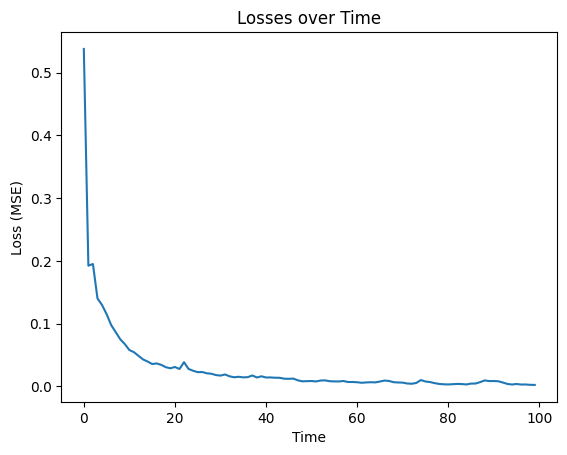

In [76]:
### DO NOT MODIFY HERE!
test_loss = 0.0
for batch_idx, (data, targets) in enumerate(test_loader):
    loss = criterion(model(data), targets)
    test_loss += loss.item()
test_loss = test_loss / len(test_loader)

train_loss = 0.0
for batch_idx, (data, targets) in enumerate(train_loader):
    loss = criterion(model(data), targets)
    train_loss += loss.item()
train_loss = train_loss / len(train_loader)

print("Train Loss:", train_loss)
print("Test Loss:", test_loss)

plt.plot(losses)
plt.title("Losses over Time")
plt.xlabel("Time")
plt.ylabel("Loss (MSE)")
plt.show()

### Section 4 : Can Regression do Classification? (10 points)
Starting at the beginning, linear models are the simplest type of model possible. They imply that our data, when graphed in a mathematical basis, can be separated by a curve that is a line (in 2 dimensions), a plane (in 3 dimensions), or a hyperplane (> 3 dimensions).


What about using what we've done for classification? Can we apply our newfound regression skills to classify things? Let's try! You already have a lot of knowledge about classification, so some of the basics from the last homework will not be repeated.

Consider the following plot

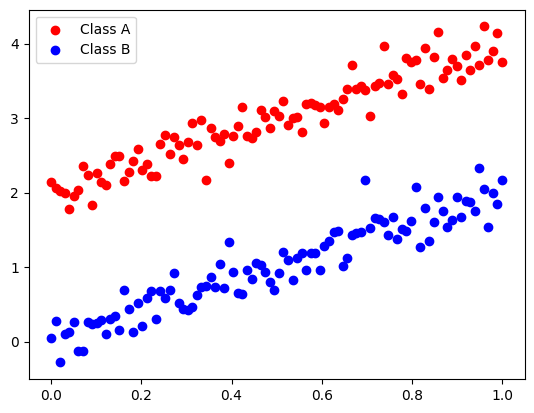

In [77]:
### DO NOT MODIFY
x_axis = np.linspace(0, 1, 100)
class_a = 2 * x_axis + 1 + np.random.normal(1, 0.2, x_axis.shape[0])
class_b = 2 * x_axis + 1 + np.random.normal(-1, 0.2, x_axis.shape[0])

plt.scatter(x_axis, class_a, color='r', label='Class A')
plt.scatter(x_axis, class_b, color='b', label='Class B')
plt.legend()

There is a very evident line that separates our classes here, one that we humans could easily draw by hand. The goal of classification is to get a computer to find this for us!

#### 4.1: Logistic Regression (10 points)

In classification tasks, the objective is to find a decision boundary that separates data points belonging to different classes. Unlike linear regression, which predicts continuous values, classification involves discrete class labels. Therefore, the model must incorporate class information during training.

A linear function is first defined as:

$$
f(x) = wx + b
$$

where:
- $w$ represents the slope,
- $b$ is the bias or intercept,
- $x$ is the input feature (or feature vector in the multivariate case).

To produce binary outputs, the following function is used to map the output of \( f(x) \) to class labels:

$$
y(x) =
\begin{cases}
1 & \text{if } f(x) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

Here, the output 1 corresponds to one class (e.g., class A), and 0 corresponds to the other (e.g., class B).

The function can be parameterized using trainable variables $\theta_1$ and $\theta_2$:

$$
f(x; \theta) = \theta_1 x + \theta_2
$$

This linear model defines a family of decision boundaries. It is assumed that an optimal set of parameters $\theta^*$ exists such that the corresponding line $f^*(x; \theta^*)$ separates the classes effectively.

To learn the parameters, a loss function must be defined. For binary classification, the [logistic (cross-entropy) loss](https://medium.com/intro-to-artificial-intelligence/logistic-regression-using-gradient-descent-bf8cbe749ceb) is used:

$$
L_\text{logistic} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$

where:
- $y_i$ $\in$ $\{0, 1\}$ is the true class label for sample $i$,
- $\hat{y}_i$ is the predicted probability of class 1 for sample $i$, defined as:

$$
\hat{y}_i = \sigma(\theta_1 x_i + \theta_2), \quad \text{where } \sigma(z) = \frac{1}{1 + e^{-z}}
$$

The [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) $\sigma(z)$ maps any real-valued input into the range (0, 1), making it suitable for probability interpretation.

The term $ f(x) = \theta_1 x + \theta_2 $ used earlier is directly related to this formulation, as it forms the input to the sigmoid function:

$$
\hat{y}_i = \sigma(f(x)) = \frac{1}{1 + e^{-f(x)}}
$$

To minimize the loss function, gradient descent is used. The gradients of the loss with respect to the parameters are given by:

$$
\frac{\partial L}{\partial \theta_1} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i) x_i
$$

$$
\frac{\partial L}{\partial \theta_2} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)
$$

TASK: Fill in the gradient update step in fit method of SimpleLogisticRegression

In [78]:

class SimpleLogisticRegression:
    def __init__(self, iterations=1000, learning_rate=0.01):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.w = None # weights are set in fit method
        self.b = 0.0

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, Y):
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(-1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros((n_features, 1))

        for _ in range(self.iterations):
            linear_model = np.dot(X, self.w) + self.b
            y_pred = self._sigmoid(linear_model)

            ### YOUR CODE HERE
            dw = (1/n_samples) * np.dot(X.T, (y_pred - Y))
            db = (1/n_samples) * np.sum(y_pred - Y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db


    def predict(self, X, threshold=0.5):
        X = X.reshape(X.shape[0], -1)
        linear_model = np.dot(X, self.w) + self.b
        probability = self._sigmoid(linear_model)
        return (probability >= threshold).astype(int)


Do not modify the below code block!

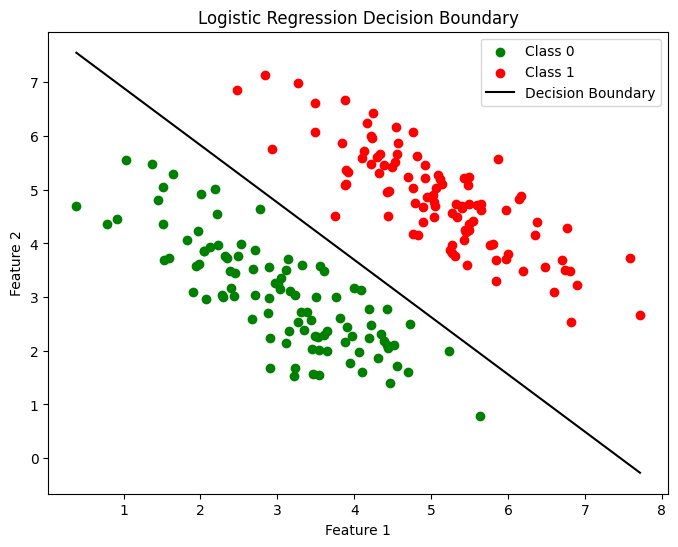

In [79]:
### DO NOT MODIFY
import numpy as np
import matplotlib.pyplot as plt

### DO NOT MODIFY
np.random.seed(0)
num_samples = 100

X0 = np.random.multivariate_normal([3, 3], [[1, -0.8],
                                            [-0.8, 1]], num_samples)
Y0 = np.zeros((num_samples, 1))
X1 = np.random.multivariate_normal([5, 5], [[1, -0.8],
                                            [-0.8, 1]], num_samples)
Y1 = np.ones((num_samples, 1))

X = np.vstack((X0, X1))
Y = np.vstack((Y0, Y1))

# Train the logistic regression model
model = SimpleLogisticRegression(iterations=1000, learning_rate=0.1)
model.fit(X, Y)

# Predict (optional; plotting uses model.w / model.b below)
# preds = model.predict(X)

# Plot the dataset and decision boundary
def plot_decision_boundary(X, Y, model):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[Y.ravel() == 0][:, 0], X[Y.ravel() == 0][:, 1], color='green', label='Class 0')
    plt.scatter(X[Y.ravel() == 1][:, 0], X[Y.ravel() == 1][:, 1], color='red', label='Class 1')

    # Decision boundary
    x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_values = -(model.w[0] * x_values + model.b) / model.w[1]
    plt.plot(x_values, y_values.ravel(), label='Decision Boundary', color='black')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(X, Y, model)


# Part 2. Real / Fake News Classification (Section 5 - Section 7)

You’ve just joined UMD News as a data scientist, and the Fact-Checking Department is begging for help 🙏🙏🙏.

They've been working 24/7 trying to spot fake news, and let’s just say... morale is low and coffee supplies are dangerously high ☕⚠️.

They need you to **build a fake news classifier** to help catch false stories automatically—so they can finally take a break (or at least a nap)  🛌😴.

They’ve sent you a dataset to get started.

### Section 5: Download, Assess, and Preprocess Data (20 points)

##### 5.1. Download the data (0 pts)

Put the two csv files (real.csv and fake.csv) into the same directory of this file. Here is a piece of code to check whether you did correctly.

In [80]:
import os
files = os.listdir('.')
print("real.csv is in the folder:", "real.csv" in files)
print("fake.csv is in the folder:", "fake.csv" in files)

real.csv is in the folder: True
fake.csv is in the folder: True


##### 5.2. Load the data and have a first glance (5 pts)
Look at the dataset. In the box below, write a paragraph describing the dataset.

In [81]:
# You may write any code you need here.
import pandas as pd
import numpy as np

real_df = pd.read_csv('real.csv')
fake_df = pd.read_csv('fake.csv')

print("REAL NEWS DATASET:")
print("Shape: ", real_df.shape)
print(real_df.head())
print(real_df.dtypes)
print(real_df.isnull().sum())
print("\n")

print("\nFAKE NEWS DATASET:")
print("Shape: ", fake_df.shape)
print(fake_df.head())
print(fake_df.dtypes)
print(fake_df.isnull().sum())
print("\n")

print("Total: ", len(real_df)+len(fake_df))

REAL NEWS DATASET:
Shape:  (5000, 4)
                                               title  \
0  Thousands march in Helsinki in far-right, anti...   
1  Marseille attacker probably radicalized by bro...   
2  U.S. farmers slam Trump's Cuba clampdown, pres...   
3  Turkey investigates reports that folk dancers ...   
4  Trump administration would ignore WTO rulings ...   

                                                text       subject  \
0  HELSINKI (Reuters) - Supporters of the far rig...     worldnews   
1  ROME (Reuters) - The brother of the man who ki...     worldnews   
2  CHICAGO (Reuters) - U.S. farm groups criticize...  politicsNews   
3  ANKARA (Reuters) - Turkey is investigating rep...     worldnews   
4  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   

                date  
0  December 6, 2017   
1   October 9, 2017   
2     June 16, 2017   
3  December 5, 2017   
4     March 1, 2017   
title      object
text       object
subject    object
date       ob

Paragraph with answer here. One point each for:
- writing a paragraph
- the size of the dataset
- what each file represents
- what each column represents
- the datatype of each column

The dataset contains two CSV files which together form a binary news classifciation dataset. There are a total of 10000 entries, 5000 per class. real.csv has all the legitimate news articles, while fake.csv has fabricated or misleading news. Both files have 4 columns: title, text, subject, and date. The title column represents the headline of the article. The text column the full body content of the article. The subject covers the topic category. The date is the publication date of the article. All of the columns are of string type in both files. Another key thing to notice is that there is no missing values across all columns in both datasets. Each row represents one individual news article.

##### 5.3. What do you think? (4 pts)
You get home from work and your friend asks you about your job. What do you think about training a classifier on this dataset?

Paragraph with answer here. We expect them to write how this is easy (all the true examples have cities associated with them) or hard (3 points), and the context of how this classifier may be used (2 points).

I think training a classifier on this dataset is going to be hard. On one hand, it seems really easy becaues the real news articles are all sourced from Reuters it looks like and they all follow a consistent format like "WASHINGTON (Reuters) -" or "ROME (Rueters) -". This means a classifier could potentially reach a high accuracy just by learning to look for this formatting rather than really understanding the content. The fake news articles, on the other hand, have much more varied writing styles. The real concern is how this classifier would be used in practice. A model that learned Reuters formatting would most likely just fail on real-world fake news that has good formatting. This means that we should be cautious about over-interpreting the results because it is hard to know if the model really "learned" to detect fake news.

##### 5.4. Check for empty entries (3 pts)
Your colleague told you: "Hey, some entries may be empty." Is that true? Count the number of entries per column that don't have information in them.

In [82]:
def count_empty_entries(df):
    for column in df.columns:
        ### TODO Add Your Code Here: Count the number of empty entries in each column
        empty_count = df[column].isnull().sum() + (df[column].astype(str).str.strip()=='').sum()

        # empty_count = None
        print(f"Column '{column}' has {empty_count} empty entries.")

print("Counting empty entries in the real dataset:")
count_empty_entries(real_df)
print("\nCounting empty entries in the fake dataset:")
count_empty_entries(fake_df)


Counting empty entries in the real dataset:
Column 'title' has 6 empty entries.
Column 'text' has 6 empty entries.
Column 'subject' has 4 empty entries.
Column 'date' has 5 empty entries.

Counting empty entries in the fake dataset:
Column 'title' has 5 empty entries.
Column 'text' has 143 empty entries.
Column 'subject' has 5 empty entries.
Column 'date' has 10 empty entries.


##### 5.5. Delete some columns and rows (1 + 2 pts)
After discussing with your team leader, you both believe **`subject` and `date` are not useful for your analysis**, so you decide to **drop them** from both datasets.

In addition, you will **remove any rows that have empty entries in the `title` or `text` column** from both datasets.


In [83]:
# 1 point
def remove_subject_and_date(df):
    # TODO Add your code here: drop the 'subject' and 'date' columns from the dataframe
    df = df.drop(columns=['subject', 'date'])
    return df

real_df = remove_subject_and_date(real_df)
fake_df = remove_subject_and_date(fake_df)
print("real_df's current columns:,", real_df.columns)
print("fake_df's current columns:,", fake_df.columns)

real_df's current columns:, Index(['title', 'text'], dtype='object')
fake_df's current columns:, Index(['title', 'text'], dtype='object')


In [84]:
# 2 points
def remove_rows_with_empty_entries(df):
    # TODO Add your code here: remove rows with any empty entries in the dataframe
    df = df.dropna()
    df = df[df['title'].str.strip() != '']
    df = df[df['text'].str.strip() != '']
    return df

real_df = remove_rows_with_empty_entries(real_df)
fake_df = remove_rows_with_empty_entries(fake_df)
print("After removing rows with empty entries:")
print("Real dataset shape after cleaning:", real_df.shape)
print("Fake dataset shape after cleaning:", fake_df.shape)

After removing rows with empty entries:
Real dataset shape after cleaning: (4988, 2)
Fake dataset shape after cleaning: (4852, 2)


##### 5.6. Remove special characters (5 pts)
You may notice there are many special characters in the text data, such as punctuation marks, numbers, and other non-alphabetic characters.

Please **remove all these special characters** from the text data in both datasets. **Only keep alphabetic characters and spaces.**

In addition, **make all the characters lower-case**.

In [85]:
def remove_special_characters(df):
    # TODO Add your code here: remove special characters from both columns.
    df = df.copy()
    df['title'] = df['title'].str.lower().str.replace('[^a-z ]', '', regex=True)
    df['text'] = df['text'].str.lower().str.replace('[^a-z ]', '', regex=True)
    df


    return df

real_df = remove_special_characters(real_df)
fake_df = remove_special_characters(fake_df)
print("After removing special characters:")
print("Real dataset shape after cleaning:", real_df.head(3))
print("\n\nFake dataset shape after cleaning:", fake_df.head(3))

After removing special characters:
Real dataset shape after cleaning:                                                title  \
0  thousands march in helsinki in farright antifa...   
1  marseille attacker probably radicalized by bro...   
2  us farmers slam trumps cuba clampdown press fo...   

                                                text  
0  helsinki reuters  supporters of the far right ...  
1  rome reuters  the brother of the man who kille...  
2  chicago reuters  us farm groups criticized pre...  


Fake dataset shape after cleaning:                                                title  \
0  ep  patrick henningsen live  crisis of america...   
1   desperate for members white supremacists beg ...   
2   black caucus demands action calls on congress...   

                                                text  
0   join patrick every wednesday at independent t...  
1  by now everyone is aware of how donald trump s...  
2  following the horrific tragedy in dallas texas...  


### Section 6. Create the training and testing test (6 pts)

Now we have finished pre-processing the data. We are now constructing a training set and a testing set to build up and evaluate our classifier.

We will follow the steps:
1. (6.1.) Assign labels to each row.
2. (6.2.) Concatenate the two tables `real_df` and `fake_df` into one data frame `union_df`.
3. (6.3.) Split the `union_df` into `train_df` and `test_df`, where the training/testing set contains 80%/20% of the data.

##### 6.1. Assign labels to each row (2 pts)
Add a `label` column to each of the data frame. For `real_df`, the `label` column is all 1. For `fake_df`, the `label` column is all 0.

In [86]:
def add_label_column(df, value):
    # TODO Add your code here: add a new column 'label' to the dataframe with the specified value
    df =df.copy()
    df['label'] = value

    return df

real_df = add_label_column(real_df, 1)  # Label for real emails
fake_df = add_label_column(fake_df, 0)  # Label for fake emails
print("After adding label column:")
print("Real dataset shape with labels:", real_df.head(3))
print("\n\nFake dataset shape with labels:", fake_df.head(3))


After adding label column:
Real dataset shape with labels:                                                title  \
0  thousands march in helsinki in farright antifa...   
1  marseille attacker probably radicalized by bro...   
2  us farmers slam trumps cuba clampdown press fo...   

                                                text  label  
0  helsinki reuters  supporters of the far right ...      1  
1  rome reuters  the brother of the man who kille...      1  
2  chicago reuters  us farm groups criticized pre...      1  


Fake dataset shape with labels:                                                title  \
0  ep  patrick henningsen live  crisis of america...   
1   desperate for members white supremacists beg ...   
2   black caucus demands action calls on congress...   

                                                text  label  
0   join patrick every wednesday at independent t...      0  
1  by now everyone is aware of how donald trump s...      0  
2  following the horrif

##### 6.2. Concatenate the two data frames into one (2 pts)

In [87]:
def concatenate_dataframes(df1, df2):
    # TODO Add your code here: concatenate the two dataframes
    combined_df = pd.concat([df1, df2], ignore_index=True)
    return combined_df

union_df = concatenate_dataframes(real_df, fake_df)
print("Combined dataset shape:", union_df.shape)
print("First 3 rows of the combined dataset:")
print(union_df.head(3))
print("\n\nLast 3 rows of the combined dataset:")
print(union_df.tail(3))

Combined dataset shape: (9840, 3)
First 3 rows of the combined dataset:
                                               title  \
0  thousands march in helsinki in farright antifa...   
1  marseille attacker probably radicalized by bro...   
2  us farmers slam trumps cuba clampdown press fo...   

                                                text  label  
0  helsinki reuters  supporters of the far right ...      1  
1  rome reuters  the brother of the man who kille...      1  
2  chicago reuters  us farm groups criticized pre...      1  


Last 3 rows of the combined dataset:
                                                  title  \
9837  cnns jim acosta schooled on the meaning of the...   
9838   donald trumps first campaign tv ad is here an...   
9839  one brutal image perfectly captures the truth ...   

                                                   text  label  
9837  we wish president trump could clone senior adv...      0  
9838  while an armed militia group of domestic te

##### 6.3. Split the dataset into training and testing sets (2 pts)

There are many ways to implement this. You could either implement the splitting from scratch, or you could use proper functions in `sklearn.model_selection`.

The printed results don't need to be exactly the same as the expected output, but they should be close.

In [88]:
def split_dataset(df, train_size=0.8):
    # TODO Add your code here: split the dataset into training and testing sets
    train_df, test_df = train_test_split(df, train_size=train_size, random_state=42)
    return train_df, test_df

train_df, test_df = split_dataset(union_df, train_size=0.8)
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
print("Proportion of training set:", len(train_df) / len(union_df))
print("Proportion of testing set:", len(test_df) / len(union_df))
print("#Positive samples in training set:", len(train_df[train_df['label'] == 1]))
print("#Negative samples in training set:", len(train_df[train_df['label'] == 0]))
print("#Positive samples in testing set:", len(test_df[test_df['label'] == 1]))
print("#Negative samples in testing set:", len(test_df[test_df['label'] == 0]))

Training dataset shape: (7872, 3)
Testing dataset shape: (1968, 3)
Proportion of training set: 0.8
Proportion of testing set: 0.2
#Positive samples in training set: 3961
#Negative samples in training set: 3911
#Positive samples in testing set: 1027
#Negative samples in testing set: 941


### Section 7: Build a classifier and evaluate its performance (29 pts)
Now we have our training set and testing set ready. We are going to train classifiers and evaluate its performance.

After discussing with your team leader,
* You are going to first encode the news, which means convert each piece of news into a fixed-length vector. And then you will train a classifier.
* You are going to try two encoders, `TfidfVectorizer` and `SentenceTransformer`. You will use `Linear SVM` on the TF-IDF vectors and `Logistic Regression` on the SentenceTransformer vectors.
* For this assignment, use **only the `text` column** (article body) as the document to classify; do not use the headline (`title`) as input.

Fill in the **classification accuracy on the test set** into the table at the end.
|  | TfidfVectorizer + Linear SVM | SentenceTransformer + Logistic Regression |
|----------|----------|----------|
| `text` only |  |  |

##### 7.1: TfidfVectorizer - Linear SVM (13 pts)

#### 7.1.1. TfidfVectorizer (5 pts)
Currently, our input is a string. Machine learning models like Linear SVM cannot receive strings as inputs. Therefore, our first step is to convert the input strings into feature vectors. We will use `TfidfVectorizer` from `sklearn.feature_extraction.text` to achieve this. You are recommended to read the documentation to facilitate your coding.

You would do the following:
1. Fit the `TfidfVectorizer` using the **training** `text` column.
2. Use the fitted vectorizer to transform the **test** `text` column.

Hint: When fitting the `TfidfVectorizer`, pay attention to the `max_features` parameter. If you find the training later on takes a very long time, consider setting an appropriate value for this parameter.

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_feature_vectors(train_df_input_column, test_df_input_column):
    # TODO Add your code here: first fit the TfidfVectorizer on the training set, then transform both the training and testing sets using the fitted vectorizer.
    vectorizer = TfidfVectorizer(max_features=10000)
    train_feature_vectors = vectorizer.fit_transform(train_df_input_column)
    test_feature_vectors = vectorizer.fit_transform(test_df_input_column)

    return train_feature_vectors, test_feature_vectors

train_tfidf_vectors, test_tfidf_vectors = extract_feature_vectors(train_df["text"], test_df["text"])
print("TF-IDF feature vectors (train):", train_tfidf_vectors.shape)
print("TF-IDF feature vectors (test): ", test_tfidf_vectors.shape)

TF-IDF feature vectors (train): (7872, 10000)
TF-IDF feature vectors (test):  (1968, 10000)


##### 7.1.2. Linear SVM (8 pts)
Train a **Linear SVM model** on the training set and evaluate its performance on the testing set. Feel free to set your own hyper-parameters.

Consider using `accuracy_score` and `classification_report` from `sklearn.metrics` to evaluate and present your results.

You don't need to match the exact values from `expected_output.ipynb`, but you shall obtain a similar format of outputs and reasonable values (e.g. accuracy not lower than 0.85).

In [90]:
def trainSVM(train_feature_vectors, train_labels, test_feature_vectors, test_labels):
    from sklearn.svm import LinearSVC
    from sklearn.metrics import accuracy_score, classification_report

    # Create and train the model
    model = LinearSVC(C=1.0, max_iter=10000, random_state=42)
    model.fit(train_feature_vectors, train_labels)

    # Make predictions on the test set
    test_predictions = model.predict(test_feature_vectors)

    # Evaluate the model
    accuracy = accuracy_score(test_labels, test_predictions)
    report = classification_report(test_labels, test_predictions, target_names=['Fake News', 'Real News'])

    print("Accuracy of Linear SVM Model:", accuracy)
    print("Classification Report:\n", report)
    return model, accuracy, report

# Prepare labels for training and testing
train_labels = train_df['label'].values
test_labels = test_df['label'].values
# Linear SVM on TF-IDF features (text column only)
model_tfidf_svm, accuracy_tfidf_svm, report_tfidf_svm = trainSVM(
    train_tfidf_vectors, train_labels,
    test_tfidf_vectors, test_labels,
)
print("Accuracy of Linear SVM (TF-IDF, text only):", accuracy_tfidf_svm)


Accuracy of Linear SVM Model: 0.48272357723577236
Classification Report:
               precision    recall  f1-score   support

   Fake News       0.48      1.00      0.65       941
   Real News       0.85      0.01      0.02      1027

    accuracy                           0.48      1968
   macro avg       0.66      0.50      0.33      1968
weighted avg       0.67      0.48      0.32      1968

Accuracy of Linear SVM (TF-IDF, text only): 0.48272357723577236


##### 7.2. SentenceTransformer - Logistic Regression (11 pts)
You will use a python package named `sentence_transformers` to convert a sentence into a 384-dimensional vector. You are encouraged to read through the documentation: [https://sbert.net/](https://sbert.net/), which describes its simple interface.

Similar to the previous task, you will first transform the **`text`** column into vectors and train a logistic regression to classify the news.

##### 7.2.1. Install Sentence Transformer (3 pts)
First you will install the sentence-transformers pakcage using pip. `pip install -U sentence-transformers` After installation, you can test-run the following codes from [https://sbert.net/](https://sbert.net/) to see whether it is successfully installed.

In [91]:
import torch
from sentence_transformers import SentenceTransformer


def _demo_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

# 1. Load a pretrained Sentence Transformer model (same name as TASK 3.2.2 for a single download)
model = SentenceTransformer("paraphrase-MiniLM-L3-v2", device=_demo_device())
print(f"Using device: {model.device}")

# The sentences to encode
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

# 2. Calculate embeddings by calling model.encode()
embeddings = model.encode(sentences)
print(embeddings.shape)
# [3, 384]

# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
print(similarities)

# tensor([[1.0000, 0.5960, 0.0138],
#         [0.5960, 1.0000, 0.0906],
#         [0.0138, 0.0906, 1.0000]])


Using device: cuda:0
(3, 384)
tensor([[1.0000, 0.5960, 0.0138],
        [0.5960, 1.0000, 0.0906],
        [0.0138, 0.0906, 1.0000]])


##### 7.2.2. Transform the `text` column into vectors using SentenceTransformer (5 pts)
**Warning: This may take longer than expected to run.** The code cell saves embeddings to `hw5_st_embeddings_text.npz` after the first full run; later runs load from disk (delete the file to recompute). On **Colab**, use **Runtime → Change runtime type → GPU** for a large speedup; **Apple Silicon** may use **MPS** automatically(ensure your have torch GPU installed instead of CPU).

**Warning:** In our test, running this cell on **CPU** took **over 312 seconds** with 2 CPU core, **38 sec** on 48  CPU cores. On **GPU**, the same operation took **22 seconds**.

 For Google Colab users (including the free tier): you can enable GPU acceleration by clicking
**Runtime → Change runtime type → T4 GPU → Save**.

In [92]:
print(os.cpu_count())

2


In [93]:
import os
import time

import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# We suggest `paraphrase-MiniLM-L3-v2` model
ST_MODEL_NAME = "paraphrase-MiniLM-L3-v2"

# Disk cache (text column only).
_ST_EMBEDDINGS_CACHE = "hw5_st_embeddings_text.npz"
_st_model = None


def _st_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def _st_batch_size(device: str) -> int:
    if device == "cuda":
        return 256
    if device == "mps":
        return 128
    return min(96, max(32, (os.cpu_count() or 4) * 4))


def get_sentence_model():
    """Load once. Uses GPU (CUDA), Apple MPS, or CPU."""
    global _st_model
    if _st_model is None:
        try:
            demo = model  # from TASK 3.2.1 cell if you ran it first
            if demo is not None:
                _st_model = demo
                return _st_model
        except NameError:
            pass

        device = _st_device()
        if device == "cpu":
            torch.set_num_threads(min(8, os.cpu_count() or 1))

        # TODO: load the pretrained model into _st_model (use ST_MODEL_NAME and device).
        _st_model = SentenceTransformer(ST_MODEL_NAME, device=device)
    return _st_model


def transform_text_column(train_col, test_col, model=None):
    model = model or get_sentence_model()
    dev_t = getattr(model.device, "type", _st_device())
    bs = _st_batch_size(dev_t if dev_t in ("cuda", "mps", "cpu") else _st_device())
    kwargs = dict(batch_size=bs, show_progress_bar=False)
    # TODO: encode train_col and test_col with model.encode(...)
    train_vecs = model.encode(train_col.tolist(), **kwargs)
    test_vecs = model.encode(test_col.tolist(), **kwargs)
    return train_vecs, test_vecs


timer1 = time.time()

if os.path.isfile(_ST_EMBEDDINGS_CACHE):
    z = np.load(_ST_EMBEDDINGS_CACHE)
    train_st_vectors = z["train"]
    test_st_vectors = z["test"]
    print("Loaded cached SentenceTransformer embeddings from", _ST_EMBEDDINGS_CACHE)
else:
    train_st_vectors, test_st_vectors = transform_text_column(train_df["text"], test_df["text"])
    print("SentenceTransformer vectors (train):", train_st_vectors.shape)
    print("SentenceTransformer vectors (test): ", test_st_vectors.shape)
    np.savez(_ST_EMBEDDINGS_CACHE, train=train_st_vectors, test=test_st_vectors)
    print("Saved embeddings to", _ST_EMBEDDINGS_CACHE, "(delete this file to recompute)")

timer2 = time.time()
print(f"Elapsed time: {timer2 - timer1} seconds")


Loaded cached SentenceTransformer embeddings from hw5_st_embeddings_text.npz
Elapsed time: 0.023036718368530273 seconds


Hey look! It's linear! What does this mean? By casting into higher dimensional spaces through a **kernel function**, we can linearly separate our data.

Of course we chose a very simple kernel.

##### 7.2.3. Logistic Regression (You can reuse majority of the code from TASK 3.1.2, see how robust the package is designed) (3 pts)
Train a **Logistic Regression model** on the training set and evaluate its performance on the testing set. Feel free to set your own hyper-parameters.

Consider using `accuracy_score` and `classification_report` from `sklearn.metrics` to evaluate and present your results.

You don't need to match the exact values from `expected_output.ipynb`, but you shall obtain a similar format of outputs and reasonable values (e.g. accuracy not lower than 0.85).

In [94]:
def trainLogisticRegression(train_feature_vectors, train_labels, test_feature_vectors, test_labels):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report

    # Create and train the model
    model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    model.fit(train_feature_vectors, train_labels)

    # Make predictions on the test set
    test_predictions = model.predict(test_feature_vectors)

    # Evaluate the model
    accuracy = accuracy_score(test_labels, test_predictions)
    report = classification_report(test_labels, test_predictions, target_names=['Fake News', 'Real News'])
    print("Accuracy of Logistic Regression Model:", accuracy)
    print("Classification Report:\n", report)
    return model, accuracy, report

# Prepare labels for training and testing
train_labels = train_df['label'].values
test_labels = test_df['label'].values
# Logistic Regression on SentenceTransformer features (text column only)
model_st_lr, accuracy_st_lr, report_st_lr = trainLogisticRegression(
    train_st_vectors, train_labels,
    test_st_vectors, test_labels,
)
print("Accuracy of Logistic Regression (SentenceTransformer, text only):", accuracy_st_lr)


Accuracy of Logistic Regression Model: 0.9679878048780488
Classification Report:
               precision    recall  f1-score   support

   Fake News       0.97      0.96      0.97       941
   Real News       0.97      0.97      0.97      1027

    accuracy                           0.97      1968
   macro avg       0.97      0.97      0.97      1968
weighted avg       0.97      0.97      0.97      1968

Accuracy of Logistic Regression (SentenceTransformer, text only): 0.9679878048780488


##### TASK 7.3. Report to your team leader (5 pts)

Finally, fill in the accuracy into the table according to your experiments.

|  | TfIdfVectorizer + Linear SVM | SentenceTransformer + Logistic Regression |
|----------|----------|----------|
| `text` only | 0.48 | 0.968 |

Send your team leader a message : "Hi manager, I recommend using **[???]** as the encoder on the **text** column. This gives an accuracy of **[???]**."

Two minutes later, your team leader replies:

"Wonderful job!!! I will promote you as the senior data scientist next year!"

Hi manager, I recommend using SentenceTransformer as the encoder on the text column. This gives an accuracy of of 96.8% on the test set, with a precision and recal of around 0.97.
